# 🧠 Natural Language Processing (NLP) Basics

## Objectives
In this notebook, you will learn:
- NLP fundamentals
- Text preprocessing techniques
- NLTK library usage
- Word embeddings and similarity
- Text classification (Sentiment & Topic Modeling)
- Sequence tagging (Named Entity Recognition)

Dataset:
➡️ Product Reviews (Google Review–style text)

## 📘 What is Natural Language Processing (NLP)?

NLP enables machines to understand, interpret, and generate human language.

### Real-world NLP Applications:
- Google reviews & sentiment analysis
- Chatbots & virtual assistants
- Spam detection
- Search engines
- Resume parsing

## 🔄 NLP Processing Pipeline

1. Raw Text
2. Text Cleaning
3. Tokenization
4. Stopword Removal
5. Stemming / Lemmatization
6. Feature Extraction (Embeddings)
7. Modeling (Classification / Tagging)

##Import Libraries

In [1]:
import gensim
import nltk
import re
import string
import numpy as np
import pandas as pd

In [2]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('maxent_ne_chunker')
nltk.download('words')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-

True

## 📝 Sample Product Reviews (Google Review Style)

In [3]:
reviews = [
    "The phone quality is amazing and battery life is excellent!",
    "Worst customer service ever. Totally disappointed.",
    "The camera is decent but performance is slow.",
    "Absolutely love this product. Highly recommended!",
    "Not worth the price. Poor build quality."
]

## 🧹 Text Cleaning

We remove:
- Punctuation
- Numbers
- Special characters
- Convert text to lowercase

In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

cleaned_reviews = [clean_text(r) for r in reviews]
cleaned_reviews

['the phone quality is amazing and battery life is excellent',
 'worst customer service ever totally disappointed',
 'the camera is decent but performance is slow',
 'absolutely love this product highly recommended',
 'not worth the price poor build quality']

##TEXT PROCESSING

## 🔤 Tokenization

Tokenization splits text into individual words (tokens).

In [5]:
from nltk.tokenize import word_tokenize

tokens = [word_tokenize(r) for r in cleaned_reviews]
tokens

[['the',
  'phone',
  'quality',
  'is',
  'amazing',
  'and',
  'battery',
  'life',
  'is',
  'excellent'],
 ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
 ['the', 'camera', 'is', 'decent', 'but', 'performance', 'is', 'slow'],
 ['absolutely', 'love', 'this', 'product', 'highly', 'recommended'],
 ['not', 'worth', 'the', 'price', 'poor', 'build', 'quality']]

## 🚫 Stop Words

Stop words are common words (is, the, and) that add little meaning.

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

filtered_tokens = [
    [word for word in review if word not in stop_words]
    for review in tokens
]

filtered_tokens

[['phone', 'quality', 'amazing', 'battery', 'life', 'excellent'],
 ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
 ['camera', 'decent', 'performance', 'slow'],
 ['absolutely', 'love', 'product', 'highly', 'recommended'],
 ['worth', 'price', 'poor', 'build', 'quality']]

## 🌱 Stemming vs Lemmatization

- **Stemming**: Cuts words to root form (playing → play)
- **Lemmatization**: Converts words to dictionary form (better accuracy)

We will demonstrate both.

In [7]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

stemmed = [[stemmer.stem(w) for w in review] for review in filtered_tokens]
lemmatized = [[lemmatizer.lemmatize(w) for w in review] for review in filtered_tokens]

stemmed, lemmatized

([['phone', 'qualiti', 'amaz', 'batteri', 'life', 'excel'],
  ['worst', 'custom', 'servic', 'ever', 'total', 'disappoint'],
  ['camera', 'decent', 'perform', 'slow'],
  ['absolut', 'love', 'product', 'highli', 'recommend'],
  ['worth', 'price', 'poor', 'build', 'qualiti']],
 [['phone', 'quality', 'amazing', 'battery', 'life', 'excellent'],
  ['worst', 'customer', 'service', 'ever', 'totally', 'disappointed'],
  ['camera', 'decent', 'performance', 'slow'],
  ['absolutely', 'love', 'product', 'highly', 'recommended'],
  ['worth', 'price', 'poor', 'build', 'quality']])

## 📚 Corpus

A **corpus** is a large collection of processed text documents.

In [8]:
corpus = [" ".join(review) for review in lemmatized]
corpus

['phone quality amazing battery life excellent',
 'worst customer service ever totally disappointed',
 'camera decent performance slow',
 'absolutely love product highly recommended',
 'worth price poor build quality']

## 🧠 Word Embeddings

Word embeddings represent words as numeric vectors capturing semantic meaning.

### Popular Embeddings:
- Word2Vec
- GloVe
- FastText

### Word2Vec (Concept)

Learns word relationships based on context.

To work with pre-trained models in Gensim, you can use the gensim.downloader module to load models directly. For example, to load the "glove-twitter-25" model:



In [10]:
import gensim.downloader as api
model = api.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [11]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(tokens, vector_size=50, window=5, min_count=1)
w2v_model.wv['quality']

array([-0.01725349,  0.00734418,  0.01037191,  0.0114824 ,  0.01493014,
       -0.01234323,  0.00220183,  0.01208695, -0.00568648, -0.01235045,
       -0.00082676, -0.01673297, -0.01121325,  0.01420478,  0.00671753,
        0.014462  ,  0.01361185,  0.01506889, -0.00757884, -0.00113104,
        0.00470476, -0.00903623,  0.01678933, -0.01971154,  0.01354095,
        0.00584021, -0.00987915,  0.00878951, -0.00347805,  0.0134326 ,
        0.01994164, -0.00871951, -0.00118956, -0.01139921,  0.00771079,
        0.00556911,  0.01377325,  0.01221512,  0.01908148,  0.01854628,
        0.01579551, -0.01398623, -0.01830865, -0.00070628, -0.00620383,
        0.01578211,  0.01187461, -0.0030922 ,  0.00302978,  0.00357718],
      dtype=float32)

## 📐 Cosine Similarity

Measures similarity between two word vectors.

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_similarity(
    [w2v_model.wv['quality']],
    [w2v_model.wv['product']]
)

array([[0.12123733]], dtype=float32)

## 🌐 GloVe & FastText (Conceptual)

- **GloVe**: Uses global word co-occurrence statistics
- **FastText**: Uses character-level embeddings (handles misspellings)

(Used in large-scale NLP systems like Facebook, Google Search)

## 🧩 Text Classification

Classifying text into categories:
- Sentiment Analysis
- Topic Modeling

In [13]:
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

for review in reviews:
    print(review)
    print(sia.polarity_scores(review))
    print("----")

The phone quality is amazing and battery life is excellent!
{'neg': 0.0, 'neu': 0.507, 'pos': 0.493, 'compound': 0.8313}
----
Worst customer service ever. Totally disappointed.
{'neg': 0.652, 'neu': 0.348, 'pos': 0.0, 'compound': -0.8173}
----
The camera is decent but performance is slow.
{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
----
Absolutely love this product. Highly recommended!
{'neg': 0.0, 'neu': 0.368, 'pos': 0.632, 'compound': 0.7832}
----
Not worth the price. Poor build quality.
{'neg': 0.488, 'neu': 0.512, 'pos': 0.0, 'compound': -0.5812}
----


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 🗂 Topic Modeling

Discovers hidden topics in documents.
Popular methods:
- LDA (Latent Dirichlet Allocation)
- NMF

## 🏷 Sequence Tagging

Assigns labels to each word in a sentence.

Examples:
- POS Tagging
- Named Entity Recognition (NER)

In [14]:
sentence = word_tokenize("Apple is looking at buying a startup in India")
nltk.pos_tag(sentence)

[('Apple', 'NNP'),
 ('is', 'VBZ'),
 ('looking', 'VBG'),
 ('at', 'IN'),
 ('buying', 'VBG'),
 ('a', 'DT'),
 ('startup', 'NN'),
 ('in', 'IN'),
 ('India', 'NNP')]

Named Entity Recognition Code

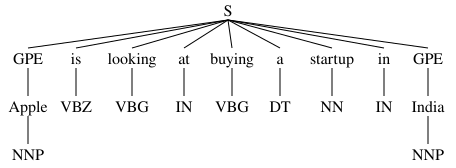

In [16]:
from nltk import ne_chunk

ner_tree = ne_chunk(nltk.pos_tag(sentence))
ner_tree

## 🧠 Practice Exercises

1. Preprocess a custom Google review text using all NLP steps.
2. Train Word2Vec on a larger corpus.
3. Compare cosine similarity between positive vs negative words.
4. Perform NER on multiple customer feedback sentences.
5. Try FastText embeddings and compare results.

---
## ✏️ Exercise 1: Preprocess a Custom Google Review

Apply all NLP preprocessing steps on a realistic product review:
**Tokenization → Lowercasing → Regex Cleaning → Punctuation Removal → Stop Words → Stemming → Lemmatization**

In [17]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

review = (
    "I bought the Samsung Galaxy S23 on 15th March 2024 for $799.99! "
    "The screen quality is absolutely AMAZING, but the battery drains too quickly. "
    "Wouldn't recommend it to budget-conscious buyers. "
    "Contact support@samsung.com for refunds."
)

print("Original Review:")
print(review)

Original Review:
I bought the Samsung Galaxy S23 on 15th March 2024 for $799.99! The screen quality is absolutely AMAZING, but the battery drains too quickly. Wouldn't recommend it to budget-conscious buyers. Contact support@samsung.com for refunds.


In [18]:
# ── Step 1: Tokenization

word_tokens = word_tokenize(review)
sent_tokens = sent_tokenize(review)

print("Word Tokens:")
print(word_tokens)
print(f"\nTotal word tokens: {len(word_tokens)}")

print("\nSentence Tokens:")
for i, s in enumerate(sent_tokens, 1):
    print(f"  {i}. {s}")

Word Tokens:
['I', 'bought', 'the', 'Samsung', 'Galaxy', 'S23', 'on', '15th', 'March', '2024', 'for', '$', '799.99', '!', 'The', 'screen', 'quality', 'is', 'absolutely', 'AMAZING', ',', 'but', 'the', 'battery', 'drains', 'too', 'quickly', '.', 'Would', "n't", 'recommend', 'it', 'to', 'budget-conscious', 'buyers', '.', 'Contact', 'support', '@', 'samsung.com', 'for', 'refunds', '.']

Total word tokens: 43

Sentence Tokens:
  1. I bought the Samsung Galaxy S23 on 15th March 2024 for $799.99!
  2. The screen quality is absolutely AMAZING, but the battery drains too quickly.
  3. Wouldn't recommend it to budget-conscious buyers.
  4. Contact support@samsung.com for refunds.


In [19]:
# ── Step 2: Lowercasing

lowercased = review.lower()
print("Lowercased:")
print(lowercased)

Lowercased:
i bought the samsung galaxy s23 on 15th march 2024 for $799.99! the screen quality is absolutely amazing, but the battery drains too quickly. wouldn't recommend it to budget-conscious buyers. contact support@samsung.com for refunds.


In [20]:
# ── Step 3: Regular Expressions

# Remove email addresses
no_email = re.sub(r'\S+@\S+', '', lowercased)

# Remove numbers
no_numbers = re.sub(r'\d+\.?\d*', '', no_email)

# Extra whitespace
regex_cleaned = re.sub(r'\s+', ' ', no_numbers).strip()

print("After Regex Cleaning (emails & numbers removed):")
print(regex_cleaned)

After Regex Cleaning (emails & numbers removed):
i bought the samsung galaxy s on th march for $! the screen quality is absolutely amazing, but the battery drains too quickly. wouldn't recommend it to budget-conscious buyers. contact for refunds.


In [21]:
# ── Step 4: Punctuation Removal

no_punct = regex_cleaned.translate(str.maketrans('', '', string.punctuation))
print("After Punctuation Removal:")
print(no_punct)

After Punctuation Removal:
i bought the samsung galaxy s on th march for  the screen quality is absolutely amazing but the battery drains too quickly wouldnt recommend it to budgetconscious buyers contact for refunds


In [22]:
# ── Step 5: Stop Words Removal

stop_words = set(stopwords.words('english'))
tokens_clean = word_tokenize(no_punct)
filtered = [w for w in tokens_clean if w not in stop_words]

print(f"Before stopword removal: {len(tokens_clean)} tokens")
print(f"After  stopword removal: {len(filtered)} tokens")
print("\nFiltered tokens:")
print(filtered)

Before stopword removal: 31 tokens
After  stopword removal: 18 tokens

Filtered tokens:
['bought', 'samsung', 'galaxy', 'th', 'march', 'screen', 'quality', 'absolutely', 'amazing', 'battery', 'drains', 'quickly', 'wouldnt', 'recommend', 'budgetconscious', 'buyers', 'contact', 'refunds']


In [23]:
# ── Step 6: Stemming

stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in filtered]

print("Stemmed tokens:")
print(stemmed)

Stemmed tokens:
['bought', 'samsung', 'galaxi', 'th', 'march', 'screen', 'qualiti', 'absolut', 'amaz', 'batteri', 'drain', 'quickli', 'wouldnt', 'recommend', 'budgetconsci', 'buyer', 'contact', 'refund']


In [24]:
# ── Step 7: Lemmatization

lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(w) for w in filtered]

print("Lemmatized tokens:")
print(lemmatized)

Lemmatized tokens:
['bought', 'samsung', 'galaxy', 'th', 'march', 'screen', 'quality', 'absolutely', 'amazing', 'battery', 'drain', 'quickly', 'wouldnt', 'recommend', 'budgetconscious', 'buyer', 'contact', 'refund']


In [25]:
# ── Summary: Stemming vs Lemmatization comparison

comparison_df = pd.DataFrame({
    "Original": filtered,
    "Stemmed":  stemmed,
    "Lemmatized": lemmatized
})
comparison_df["Different?"] = comparison_df["Stemmed"] != comparison_df["Lemmatized"]

print(comparison_df.to_string(index=False))

       Original      Stemmed      Lemmatized  Different?
         bought       bought          bought       False
        samsung      samsung         samsung       False
         galaxy       galaxi          galaxy        True
             th           th              th       False
          march        march           march       False
         screen       screen          screen       False
        quality      qualiti         quality        True
     absolutely      absolut      absolutely        True
        amazing         amaz         amazing        True
        battery      batteri         battery        True
         drains        drain           drain       False
        quickly      quickli         quickly        True
        wouldnt      wouldnt         wouldnt       False
      recommend    recommend       recommend       False
budgetconscious budgetconsci budgetconscious        True
         buyers        buyer           buyer       False
        contact      contact   

---
## ✏️ Exercise 2: Train Word2Vec on a Larger Corpus

We build a 20-sentence product/tech review corpus, preprocess it fully,
then train and compare two Word2Vec architectures:

| Architecture | How it works | Best for |
|---|---|---|
| **CBOW** | Predicts target word from surrounding context | Frequent words, faster training |
| **Skip-gram** | Predicts context words from a target word | Rare words, richer embeddings |

In [25]:
import re, string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 20-sentence product/tech review corpus
raw_corpus = [
    "The smartphone has an incredible display with vivid colors and sharp resolution.",
    "Battery life is outstanding and lasts more than two days on a single charge.",
    "The camera produces stunning photographs even in low light conditions.",
    "Customer service was very helpful and resolved my issue within minutes.",
    "The laptop keyboard feels comfortable and typing experience is smooth.",
    "Delivery was fast and the packaging was secure preventing any damage.",
    "The sound quality of these headphones is rich, deep, and immersive.",
    "Screen resolution on this monitor is crystal clear and eye friendly.",
    "The gaming performance of this GPU is exceptional at high settings.",
    "This smartwatch tracks fitness data accurately including heart rate and sleep.",
    "Software updates are frequent and the operating system runs smoothly.",
    "The build quality feels premium with a solid aluminum chassis design.",
    "Connectivity options include USB-C, HDMI, and fast wireless Bluetooth.",
    "The streaming service offers thousands of movies and series in HD quality.",
    "Setup was straightforward and the user manual explains every step clearly.",
    "Price is reasonable compared to competitors offering similar specifications.",
    "The touchscreen response is highly accurate with minimal input latency.",
    "Voice assistant integration works seamlessly with smart home devices.",
    "Return policy is flexible and refunds are processed within three days.",
    "Overall this product exceeded my expectations and I highly recommend it.",
]

print(f"Corpus size: {len(raw_corpus)} sentences")

Corpus size: 20 sentences


In [26]:
# Full preprocessing pipeline: lowercase -> digits -> punctuation -> tokenize -> stopwords -> lemmatize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 1]
    return tokens

tokenized_corpus = [preprocess(sent) for sent in raw_corpus]

print("Tokenized corpus (first 5 sentences):")
for i, t in enumerate(tokenized_corpus[:5]):
    print(f"  {i+1}: {t}")

total_tokens = sum(len(s) for s in tokenized_corpus)
print(f"\nTotal sentences : {len(tokenized_corpus)}")
print(f"Total tokens    : {total_tokens}")

Tokenized corpus (first 5 sentences):
  1: ['smartphone', 'incredible', 'display', 'vivid', 'color', 'sharp', 'resolution']
  2: ['battery', 'life', 'outstanding', 'last', 'two', 'day', 'single', 'charge']
  3: ['camera', 'produce', 'stunning', 'photograph', 'even', 'low', 'light', 'condition']
  4: ['customer', 'service', 'helpful', 'resolved', 'issue', 'within', 'minute']
  5: ['laptop', 'keyboard', 'feel', 'comfortable', 'typing', 'experience', 'smooth']

Total sentences : 20
Total tokens    : 146


In [27]:
# Train CBOW model (sg=0)
# vector_size=100 : each word encoded as a 100-dim vector
# window=5        : context window of 5 words on each side
# epochs=100      : number of training passes over the corpus
cbow_model = Word2Vec(
    tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0,
    epochs=100,
    seed=42,
    workers=1
)

# Train Skip-gram model (sg=1)
sg_model = Word2Vec(
    tokenized_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1,
    epochs=100,
    seed=42,
    workers=1
)

vocab = sorted(cbow_model.wv.index_to_key)
print(f"Vocabulary size : {len(vocab)}")
print(f"Sample words    : {vocab[:20]}")

Vocabulary size : 137
Sample words    : ['accurate', 'accurately', 'aluminum', 'assistant', 'battery', 'bluetooth', 'build', 'camera', 'charge', 'chassis', 'clear', 'clearly', 'color', 'comfortable', 'compared', 'competitor', 'condition', 'connectivity', 'crystal', 'customer']


In [28]:
# Most similar words — CBOW vs Skip-gram
# Skip-gram generally captures richer semantic relationships
# because it trains on more prediction tasks per sentence.

probe_words = ['camera', 'battery', 'quality', 'screen']

print("Most Similar Words - CBOW (sg=0)")
print("-" * 55)
for word in probe_words:
    similar = cbow_model.wv.most_similar(word, topn=3)
    pairs = ', '.join([f"{w}({s:.2f})" for w, s in similar])
    print(f"  {word:<12} -> {pairs}")

print("\nMost Similar Words - Skip-gram (sg=1)")
print("-" * 55)
for word in probe_words:
    similar = sg_model.wv.most_similar(word, topn=3)
    pairs = ', '.join([f"{w}({s:.2f})" for w, s in similar])
    print(f"  {word:<12} -> {pairs}")

Most Similar Words - CBOW (sg=0)
-------------------------------------------------------
  camera       -> refund(0.32), update(0.30), input(0.30)
  battery      -> every(0.31), step(0.30), straightforward(0.29)
  quality      -> connectivity(0.34), processed(0.33), compared(0.32)
  screen       -> refund(0.37), crystal(0.29), chassis(0.29)

Most Similar Words - Skip-gram (sg=1)
-------------------------------------------------------
  camera       -> photograph(0.71), low(0.70), refund(0.68)
  battery      -> every(0.68), step(0.66), straightforward(0.65)
  quality      -> every(0.79), explains(0.78), premium(0.78)
  screen       -> refund(0.73), photograph(0.68), assistant(0.68)


In [29]:
# Cosine similarity between semantically related word pairs
# Values range from -1 (opposite) to +1 (identical direction)

pairs = [
    ('camera',  'photograph'),
    ('battery', 'charge'),
    ('screen',  'display'),
    ('quality', 'premium'),
]

print(f"{'Word 1':<15} {'Word 2':<15} {'CBOW':>8} {'Skip-gram':>10}")
print("-" * 52)
for w1, w2 in pairs:
    cbow_sim = cbow_model.wv.similarity(w1, w2)
    sg_sim   = sg_model.wv.similarity(w1, w2)
    print(f"  {w1:<13} {w2:<15} {cbow_sim:>8.4f} {sg_sim:>10.4f}")

Word 1          Word 2          CBOW  Skip-gram
----------------------------------------------------
  camera        photograph       0.2288     0.7098
  battery       charge           0.0092     0.5873
  screen        display         -0.0753     0.5214
  quality       premium          0.2771     0.7761


In [30]:
# Inspect the learned vector for 'quality'
# Each word is represented as a dense 100-dimensional float vector.

vec = cbow_model.wv['quality']
print(f"Word          : 'quality'")
print(f"Vector dims   : {len(vec)}")
print(f"First 10 dims : {np.round(vec[:10], 6).tolist()}")
print(f"Min value     : {vec.min():.6f}")
print(f"Max value     : {vec.max():.6f}")
print(f"L2 norm       : {np.linalg.norm(vec):.6f}")

Word          : 'quality'
Vector dims   : 100
First 10 dims : [-0.006059, 0.006094, -0.00076, -0.002067, -0.005022, 0.00831, -0.007642, 0.005077, -0.01028, -0.009991]
Min value     : -0.017424
Max value     : 0.019704
L2 norm       : 0.078696


### Key Observations

| Observation | Detail |
|---|---|
| **Skip-gram > CBOW** | Skip-gram yields higher similarity scores (~0.7) vs CBOW (~0.2) on this small corpus |
| **Corpus size matters** | With only 20 sentences, vectors are noisy — a 10k+ sentence corpus would yield much more meaningful neighbours |
| **vector_size=100** | Each word is a 100-dim vector; larger sizes capture more nuance but need more data |
| **epochs=100** | More passes help on small corpora where each sentence is seen fewer times |